# Loading results

In [1]:
import os
import pandas as pd
import plotnine as pln

In [2]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/cellular/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/cellular/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

In [3]:
cols = ['Model', 'Source', 'Split', 'Dataset', 
       'Fold', 'R2_score_train', 'MAE_score_train', 'RMSE_score_train',
       'R2_score_test', 'MAE_score_test', 'RMSE_score_test', 'rho_score_train',
       'rho_score_test', 'num_nonzero_coefs']

In [4]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res


lassocv = pd.DataFrame()
for model in ['esm2_650M', 'esmc_600M', 'esm2_3B_Sawhney', 'esm2_650M_CRVDB', 'esm2_650M_URVDB']:
    for source in ['viral', 'cellular']:
        for method in ['pool_split', 'site_split']:
            res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            
            lassocv = pd.concat([lassocv, res], ignore_index=True)

rename_map = {
    'esm2_650M':'ESM-2 650M',
    'esmc_600M':'ESM C 600M',
    'esm2_650M_CRVDB':'ESM-2-CRVDB', 
    'esm2_650M_URVDB':'ESM-2-URVDB', 
    'esm2_3B_Sawhney':'ESM-2 3B Sawhney',
    'pool_split':'Pooled Split',
    'site_split':'Site Split',
    }

lassocv.replace(rename_map, inplace=True)
#lassocv = lassocv.groupby(['Model', 'Source', 'Dataset', 'Split'], as_index=False)[cols].mean()
lassocv = lassocv[cols]
lassocv['prot_length'] = lassocv['Dataset'].map(prot_lengths)
lassocv

,Model,Source,Split,Dataset,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_nonzero_coefs,prot_length
0,ESM-2 650M,viral,Pooled Split,IAV_NA_Jiang,1,0.567082,0.489658,0.663904,0.506940,0.531408,0.674557,0.762675,0.692692,69,453
1,ESM-2 650M,viral,Pooled Split,IAV_NA_Jiang,2,0.570201,0.469076,0.621080,0.406886,0.721835,0.901440,0.764662,0.636510,56,453
2,ESM-2 650M,viral,Pooled Split,IAV_NA_Jiang,3,0.632405,0.448990,0.602389,0.419914,0.609419,0.776396,0.797082,0.557599,78,453
3,ESM-2 650M,viral,Pooled Split,IAV_NA_Jiang,4,0.647898,0.417984,0.571899,0.320818,0.752558,0.932656,0.816541,0.566546,71,453
4,ESM-2 650M,viral,Pooled Split,IAV_NA_Jiang,5,0.597474,0.470227,0.627029,0.420380,0.637955,0.795527,0.792217,0.552820,66,453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3695,ESM-2-URVDB,cellular,Site Split,PABP_YEAST_Fields2013_singles,1,0.644960,0.462335,0.593943,0.295245,0.692323,0.840458,0.792576,0.524371,70,577
3696,ESM-2-URVDB,cellular,Site Split,PABP_YEAST_Fields2013_singles,2,0.720030,0.413347,0.514137,0.462085,0.623377,0.806151,0.825986,0.704590,126,577
3697,ESM-2-URVDB,cellular,Site Split,PABP_YEAST_Fields2013_singles,3,0.630090,0.490554,0.620232,0.214835,0.671658,0.800389,0.798388,0.410235,62,577
3698,ESM-2-URVDB,cellular,Site Split,PABP_YEAST_Fields2013_singles,4,0.707753,0.417339,0.539156,0.559275,0.540182,0.666259,0.819301,0.726292,116,577


In [ ]:
#lassocv.to_csv('../experiments/compiled_results/res_lassoCV_all_models.csv')

# PLotting results

In [5]:
cols = ['R2_score_train', 'MAE_score_train', 'RMSE_score_train','rho_score_train',
       'R2_score_test', 'MAE_score_test', 'RMSE_score_test', 'rho_score_test', 'num_nonzero_coefs']

lassocv = pd.read_csv('../experiments/compiled_results/res_lassoCV_all_models.csv', index_col=0)
lassocv = lassocv.groupby(['Model', 'Source', 'Dataset', 'Split'], as_index=False)[cols].mean()

In [6]:
res_esm2 = lassocv.query('Model == "ESM-2 650M"').copy()
res_esm2['Source'] = pd.Categorical(res_esm2['Source'], categories=['viral', 'cellular'])
res_esm2['prot_length'] = res_esm2['Dataset'].map(prot_lengths)
res_esm2

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,prot_length
296,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.593274,0.473718,0.637422,0.794904,0.486188,0.525113,0.717140,0.738094,444.8,346
297,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Site Split,0.374695,0.604338,0.795778,0.647042,0.231793,0.647925,0.845461,0.504309,79.6,346
298,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.556010,0.529118,0.665334,0.764524,0.468531,0.579832,0.733204,0.713379,590.4,439
299,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Site Split,0.362078,0.643427,0.798541,0.642935,0.243568,0.700345,0.868268,0.545077,89.6,439
300,ESM-2 650M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.360828,0.607812,0.800282,0.562654,0.256701,0.650875,0.857956,0.474479,533.0,439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,ESM-2 650M,viral,SARS2_RBD_binding_Starr,Site Split,0.238382,0.650661,0.870498,0.389841,0.033222,0.719386,0.968608,0.200680,34.4,1273
440,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Pooled Split,0.729695,0.409088,0.520078,0.843533,0.574433,0.506460,0.650963,0.751288,562.6,1273
441,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Site Split,0.120889,0.818213,0.930678,0.289695,0.034882,0.875149,0.999084,0.193756,16.4,1273
442,ESM-2 650M,viral,SARS2_XBB15_RBD_Taylor,Pooled Split,0.666417,0.440333,0.577750,0.693423,-0.196764,0.541360,1.001461,0.610699,454.0,201


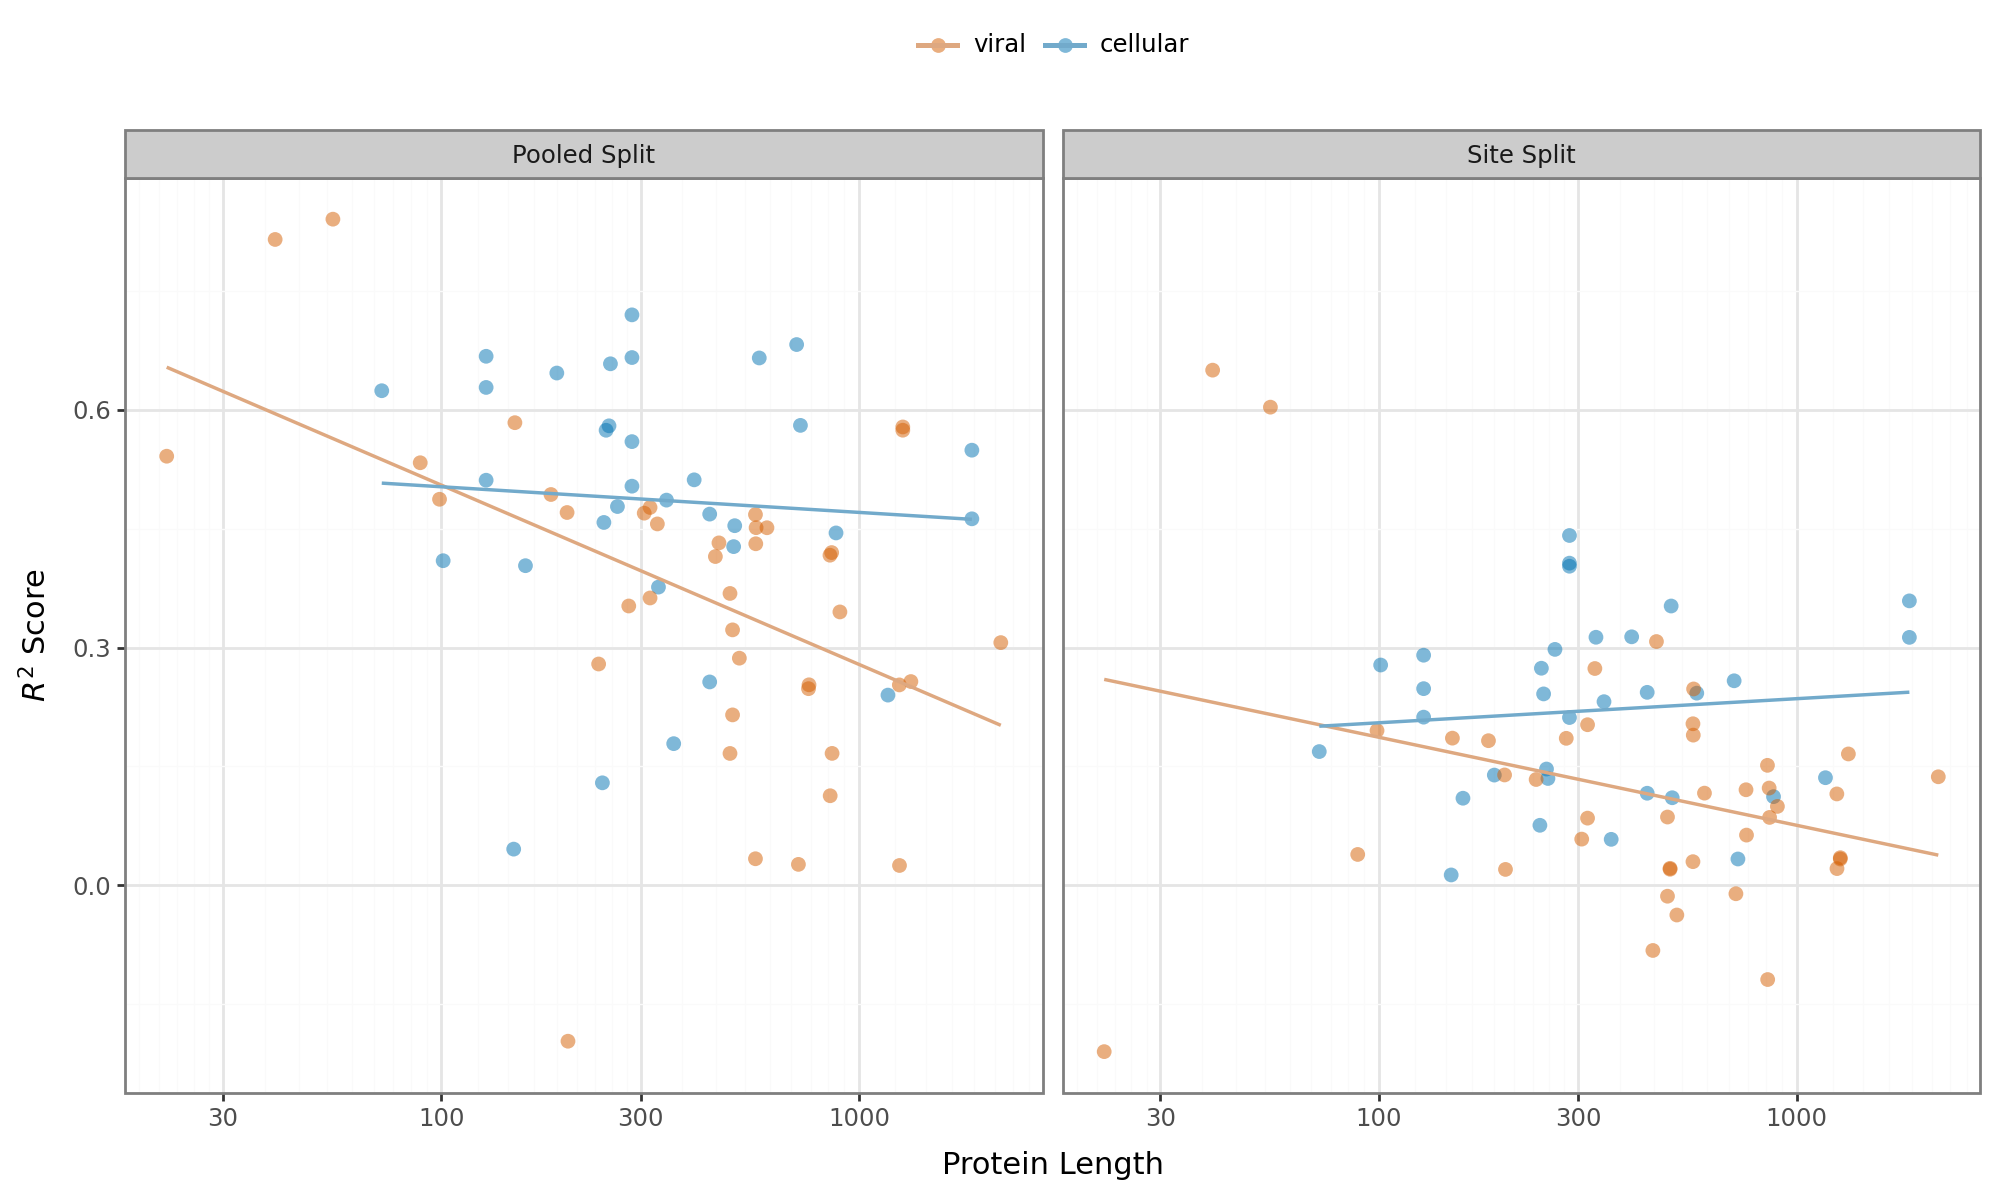

In [ ]:
plot = (
    pln.ggplot(res_esm2, pln.aes(x='prot_length', y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.facet_wrap('Split')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score")
    + pln.theme_bw()
    + pln.theme(figure_size=(10, 6), legend_position='top',legend_title=pln.element_blank())

)
plot#.save(filename='../experiments/protein_length_vs_lassocv_r2_full.png', dpi=600)

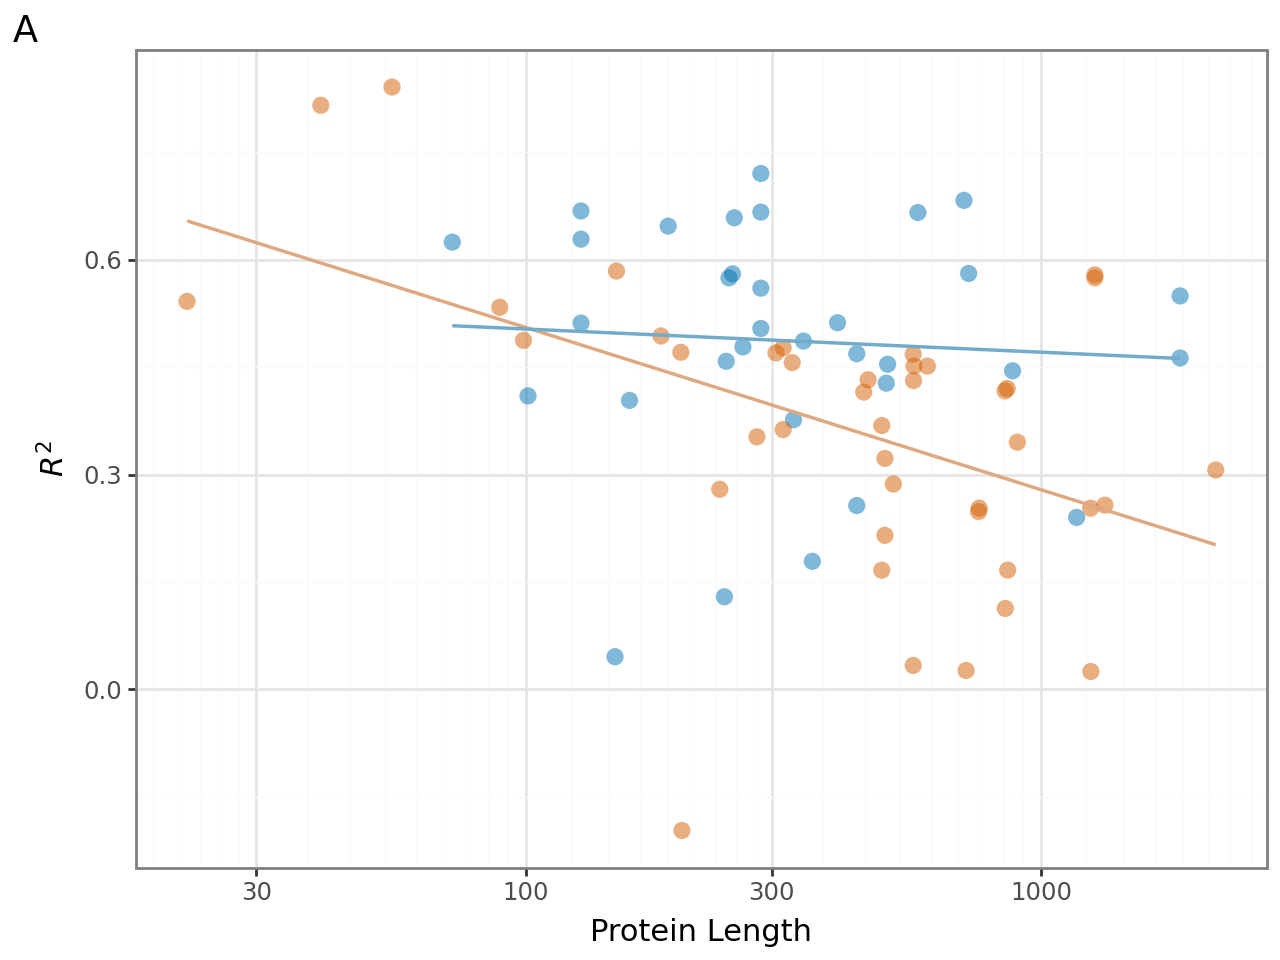

In [7]:
esm2_pooled = res_esm2.query('Split == "Pooled Split"')
p1 = (
    pln.ggplot(esm2_pooled, pln.aes(x='prot_length', y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3.5, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.scale_x_log10()
    + pln.labs(
        x="Protein Length", 
        y="$R^2$",
        tag="A")
    + pln.theme_bw()
    + pln.theme(
        legend_position='none', legend_title=pln.element_blank())
)
p1

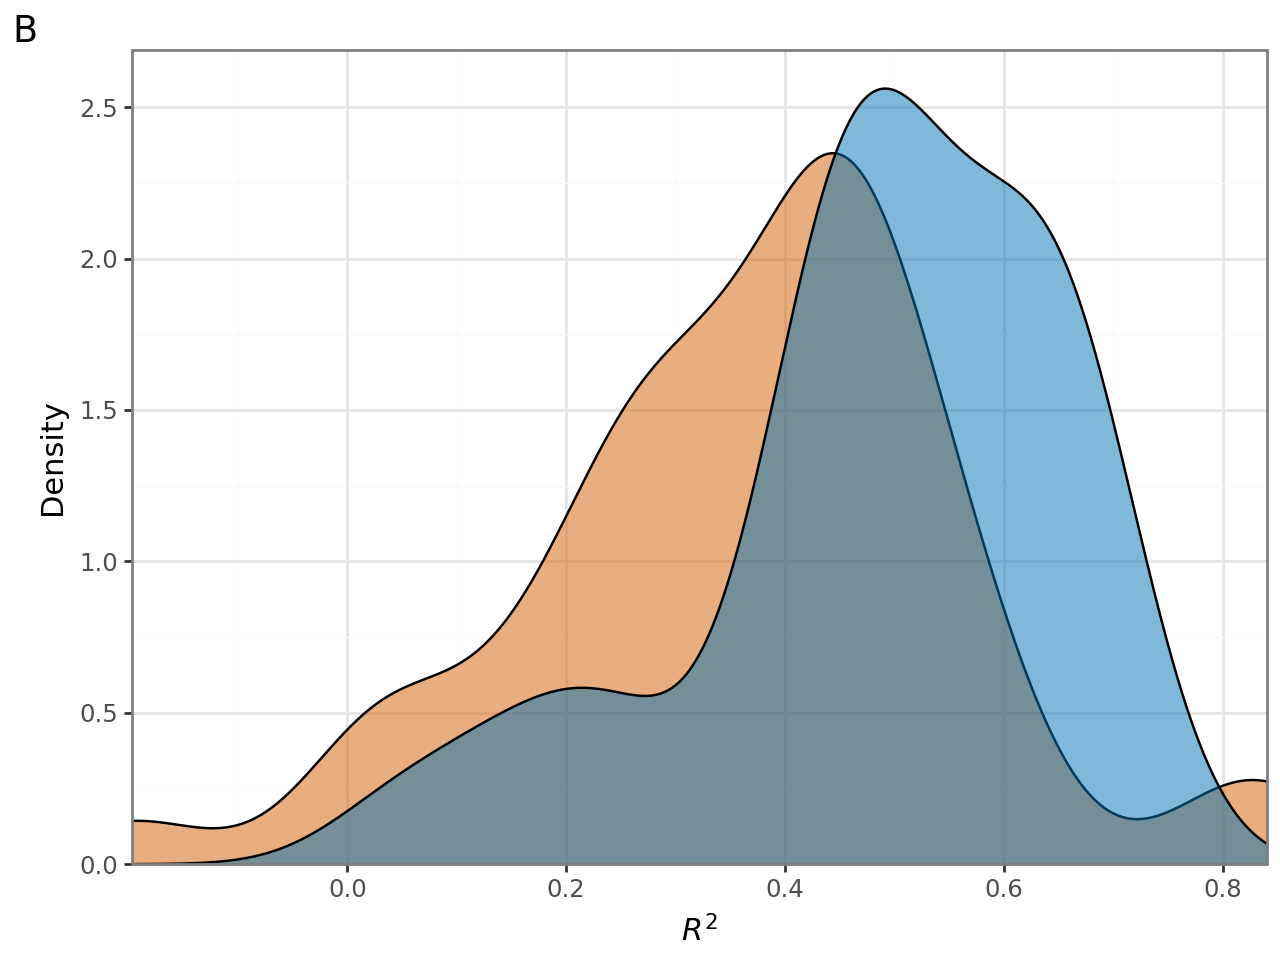

In [9]:
p2 = (
    pln.ggplot(esm2_pooled, pln.aes(x='R2_score_test'))
    + pln.geom_density(pln.aes(fill='Source'),  alpha=0.5)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.labs(
        x="$R^2$", 
        y="Density",
        tag="B")
    + pln.theme_bw()
    + pln.theme(
        #figure_size=(4.5, 3.5), 
        legend_position='none',
        legend_title=pln.element_blank())

)
p2

# Fine tuned models

In [11]:
res_full = lassocv
res_full ['Source'] = pd.Categorical(res_full['Source'], categories=['viral', 'cellular'])
res_full['Model'] = pd.Categorical(res_full['Model'], categories=['ESM-2 650M', 'ESM C 600M', 'ESM-2-CRVDB', 'ESM-2-URVDB', 'ESM-2 3B Sawhney'])
res_full['prot_length'] = res_full['Dataset'].map(prot_lengths)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 29 rows containing non-finite values.


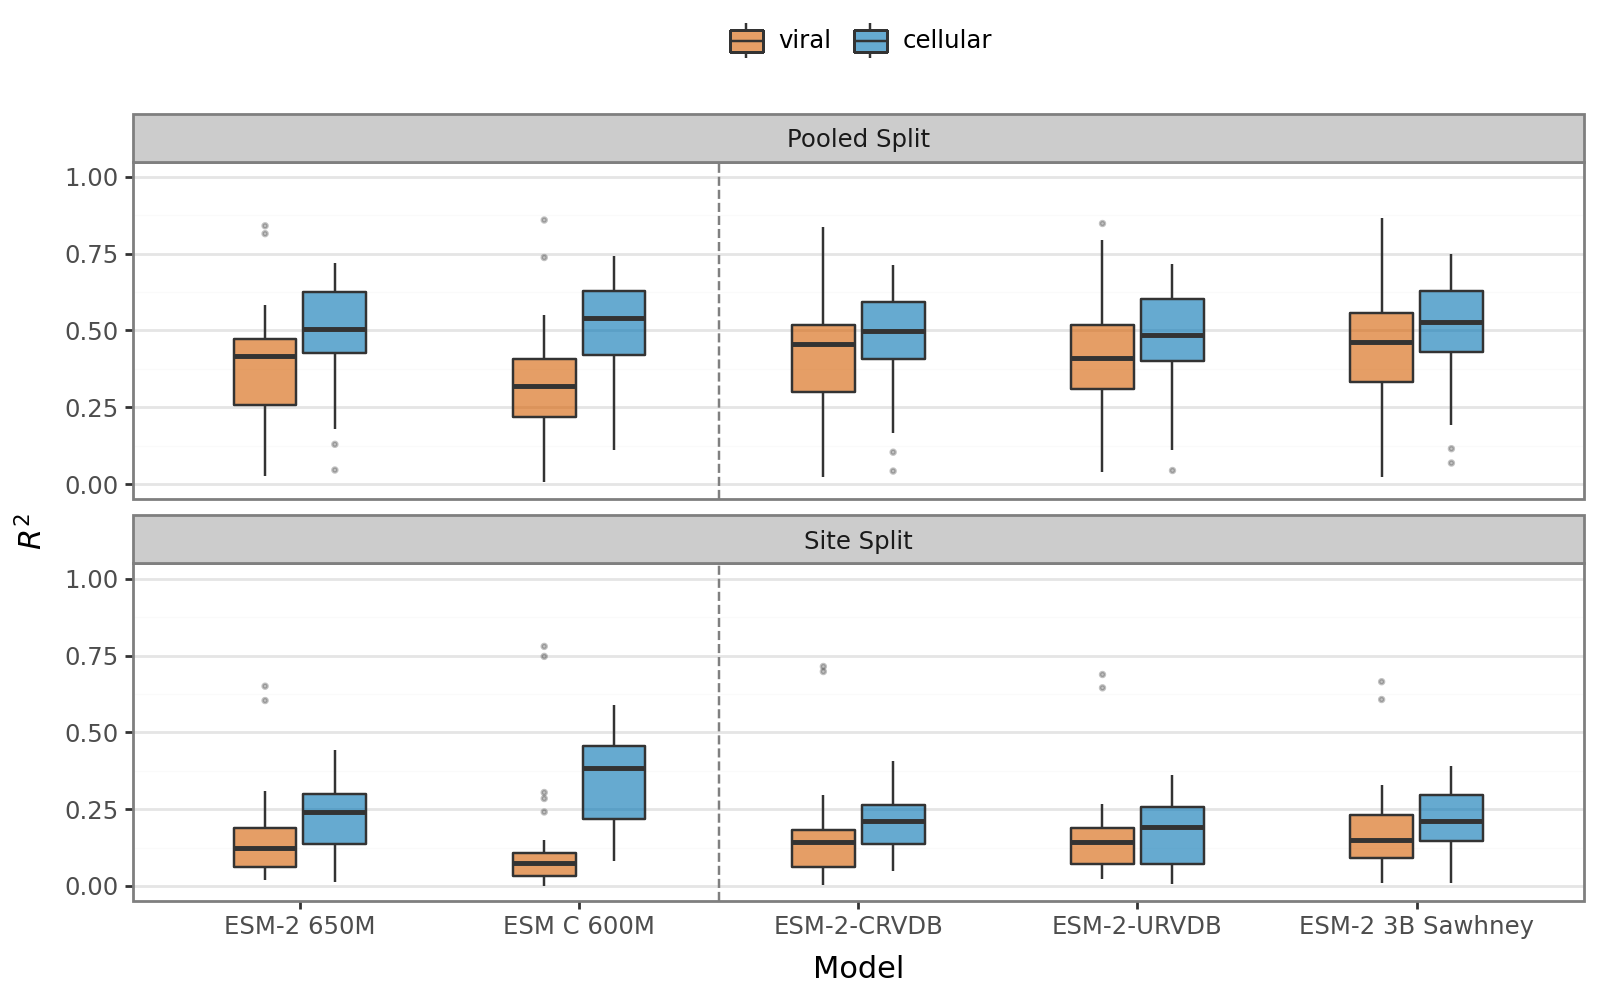

In [17]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Model', y='R2_score_test', fill='Source'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5, alpha=0.6)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_vline(xintercept=2.5, linetype='dashed', color='gray', size=0.5)
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.facet_wrap('~Split', nrow=2)
    + pln.ylim(0,1)
    + pln.theme(
        figure_size=(8, 5),
        panel_grid_major_x=pln.element_blank(),
        legend_position='top',
        legend_title=pln.element_blank(),
        
    )
)

plot#.save(filename='../experiments/lassoCV_finetuned_models.png', dpi=600)

In [12]:
res_full_pooled = res_full.query('Split == "Pooled Split"')
res_full_pooled

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,prot_length
0,ESM C 600M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.544940,0.502568,0.674223,0.763363,0.476794,0.532886,0.723885,0.730510,301.6,346
2,ESM C 600M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.473849,0.583160,0.724281,0.703427,0.420559,0.613820,0.765567,0.667434,335.6,439
4,ESM C 600M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.303514,0.633591,0.835410,0.527946,0.231265,0.664253,0.872660,0.464384,411.0,439
6,ESM C 600M,cellular,BG_STRSQ_hmmerbit,Pooled Split,0.586958,0.462587,0.641609,0.757999,0.539194,0.488546,0.682969,0.731760,118.6,501
8,ESM C 600M,cellular,BLAT_ECOLX_Ostermeier2014,Pooled Split,0.699910,0.431016,0.547510,0.864369,0.653427,0.461392,0.589177,0.837835,229.6,286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,ESM-2-URVDB,viral,SARS2_PLPRO_activity_Wu,Pooled Split,0.696530,0.442048,0.551820,0.802155,0.538994,0.535514,0.673979,0.716917,708.0,316
732,ESM-2-URVDB,viral,SARS2_PRD0038_RBD_Starr,Pooled Split,0.655388,0.435380,0.587529,0.636660,0.517681,0.482342,0.688893,0.579925,310.6,200
734,ESM-2-URVDB,viral,SARS2_RBD_binding_Starr,Pooled Split,0.769185,0.350650,0.477280,0.764901,0.656053,0.443538,0.599993,0.703929,622.2,1273
736,ESM-2-URVDB,viral,SARS2_RBD_expression_Starr,Pooled Split,0.764292,0.379187,0.485522,0.859415,0.627369,0.478313,0.609208,0.777565,629.4,1273


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 2 rows containing non-finite values.


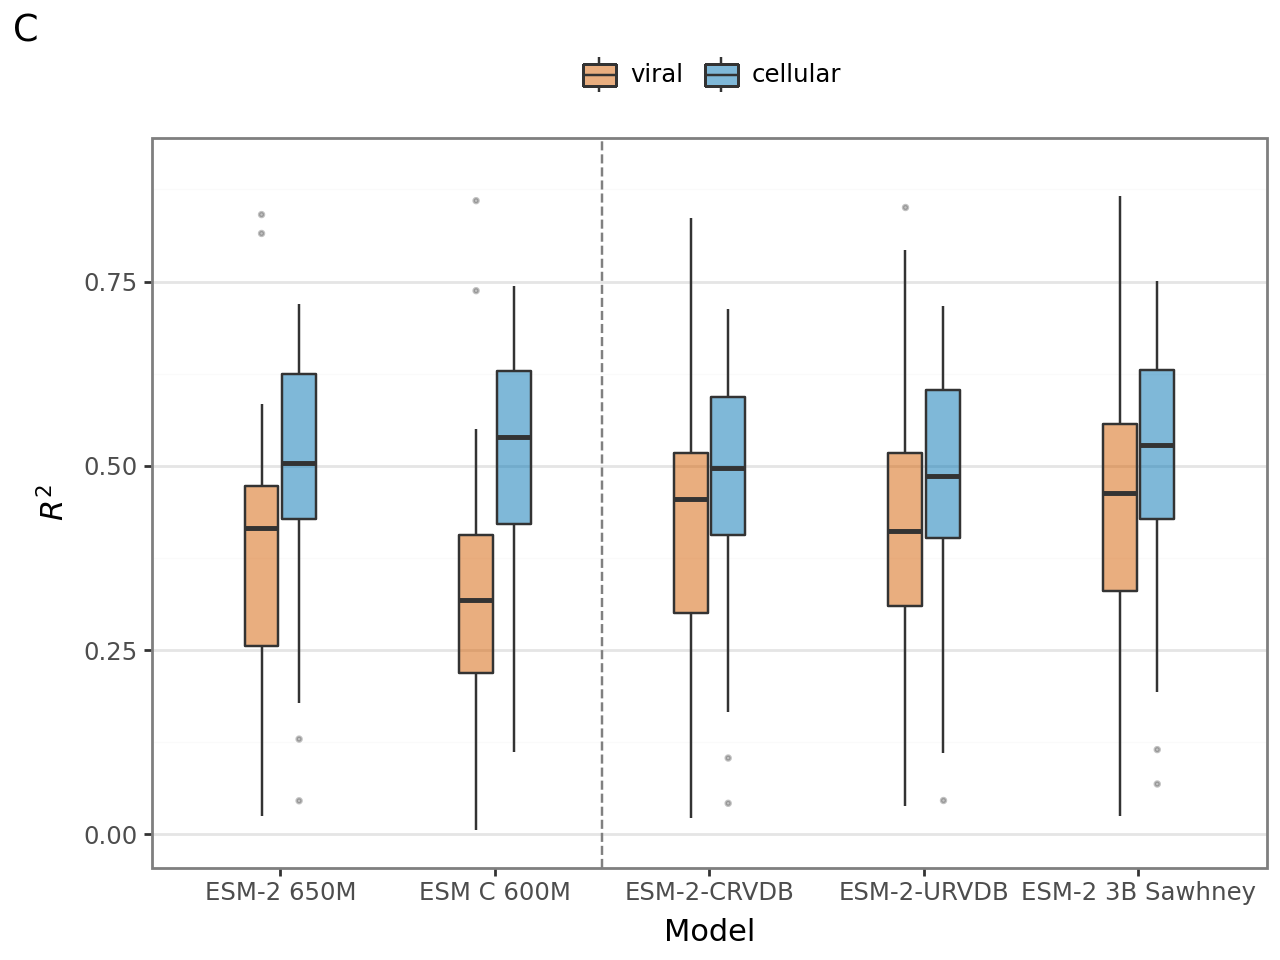

In [13]:
p3 = (
    pln.ggplot(res_full_pooled, pln.aes(x='Model', y='R2_score_test',fill='Source'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.35, alpha=0.5)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_vline(xintercept=2.5, linetype='dashed', color='gray', size=0.5)
    + pln.labs(
        x='Model',
        y='$R^2$',
        tag='C'
    )
    + pln.theme_bw()
    + pln.ylim(0,.9)
    + pln.theme(
        legend_position='top',
        panel_grid_major_x=pln.element_blank(),
        legend_title=pln.element_blank(),
        legend_key=pln.element_rect(fill='white', color='black')
        )
)

p3

# Composed figure

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 2 rows containing non-finite values.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 2 rows containing non-finite values.


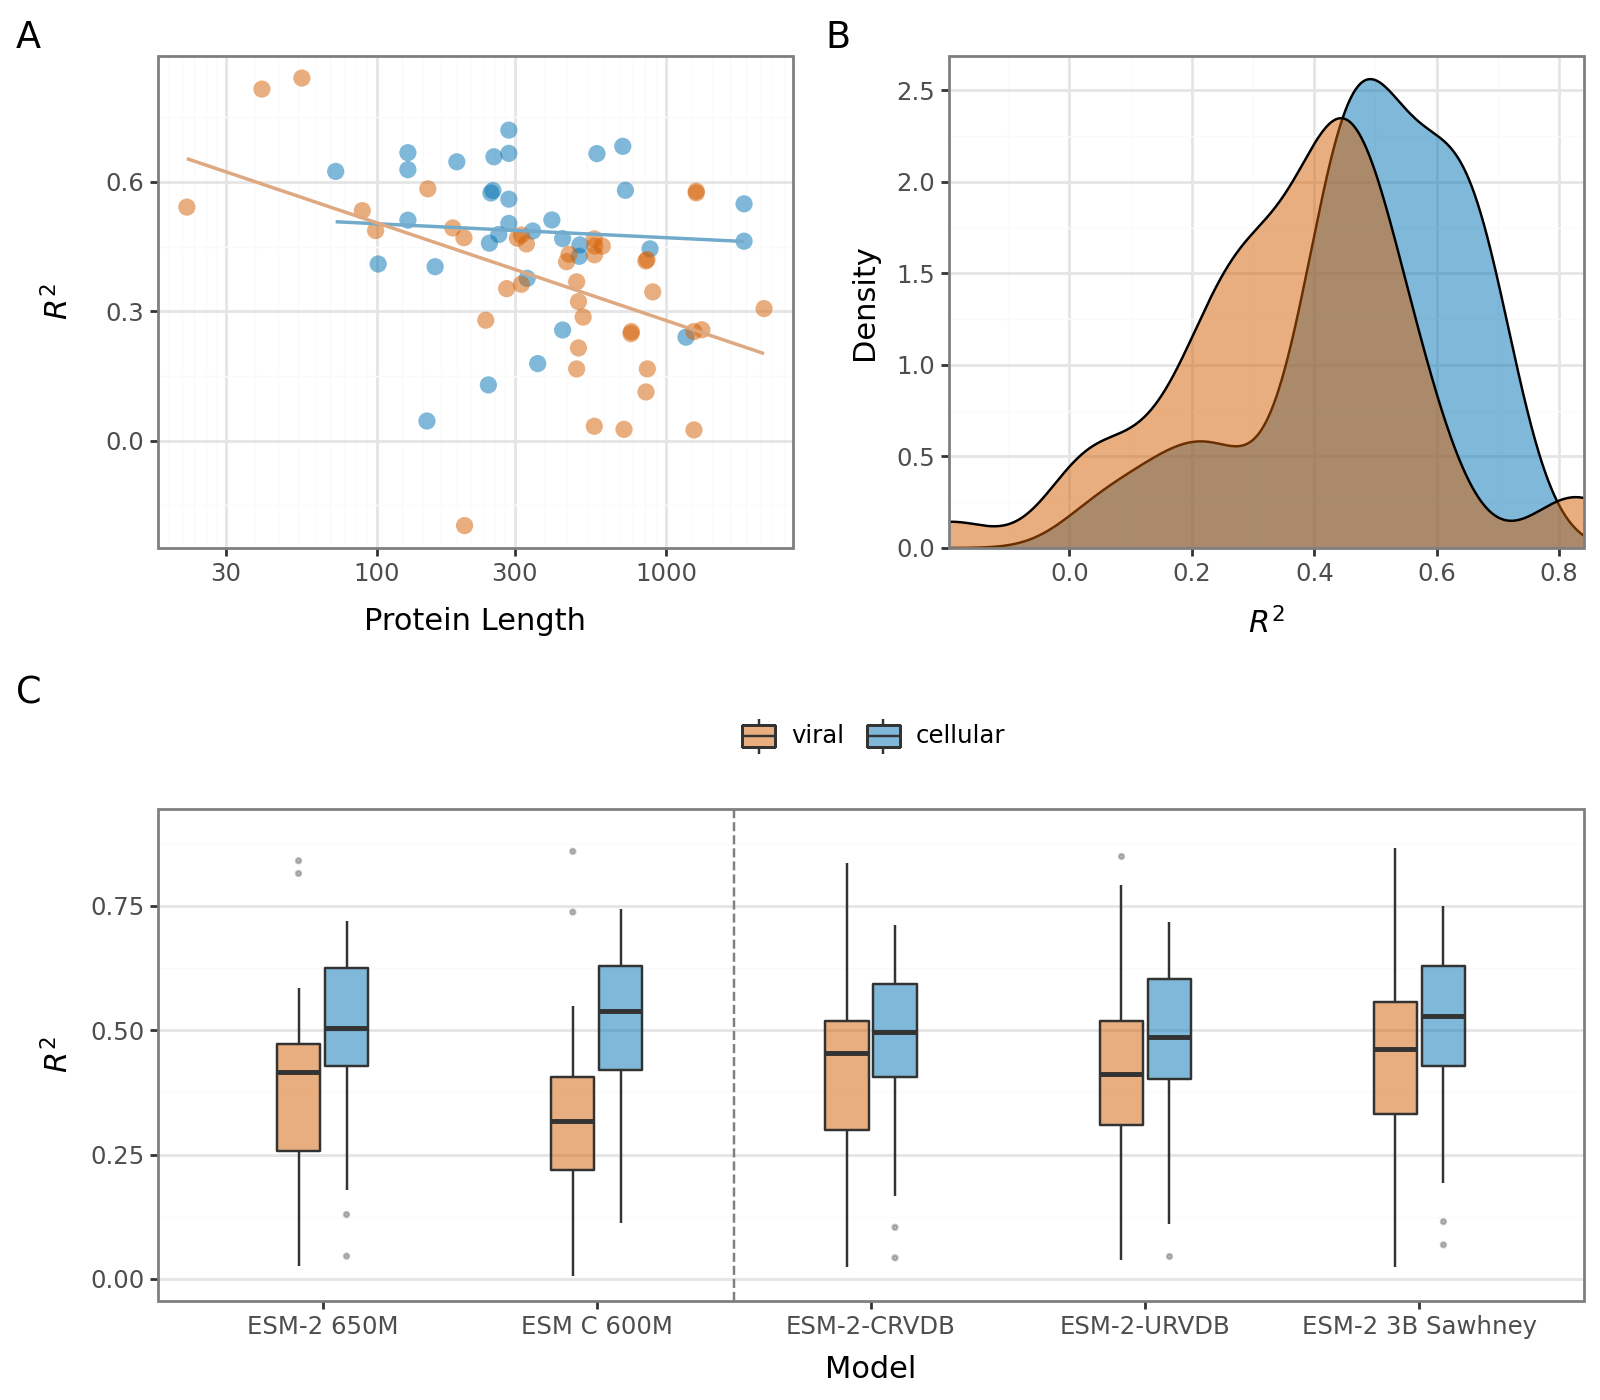

In [17]:
comp = (p1 | p2) / p3
plot = comp + pln.theme(figure_size=(8, 7.))
#plot.save(filename='../experiments/figures/comp1_pLMs_res.png', dpi=600)
plot

# Lasso results all models

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 8 x 5 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: ../experiments/figures/fig4_site_x_random_all_models.png


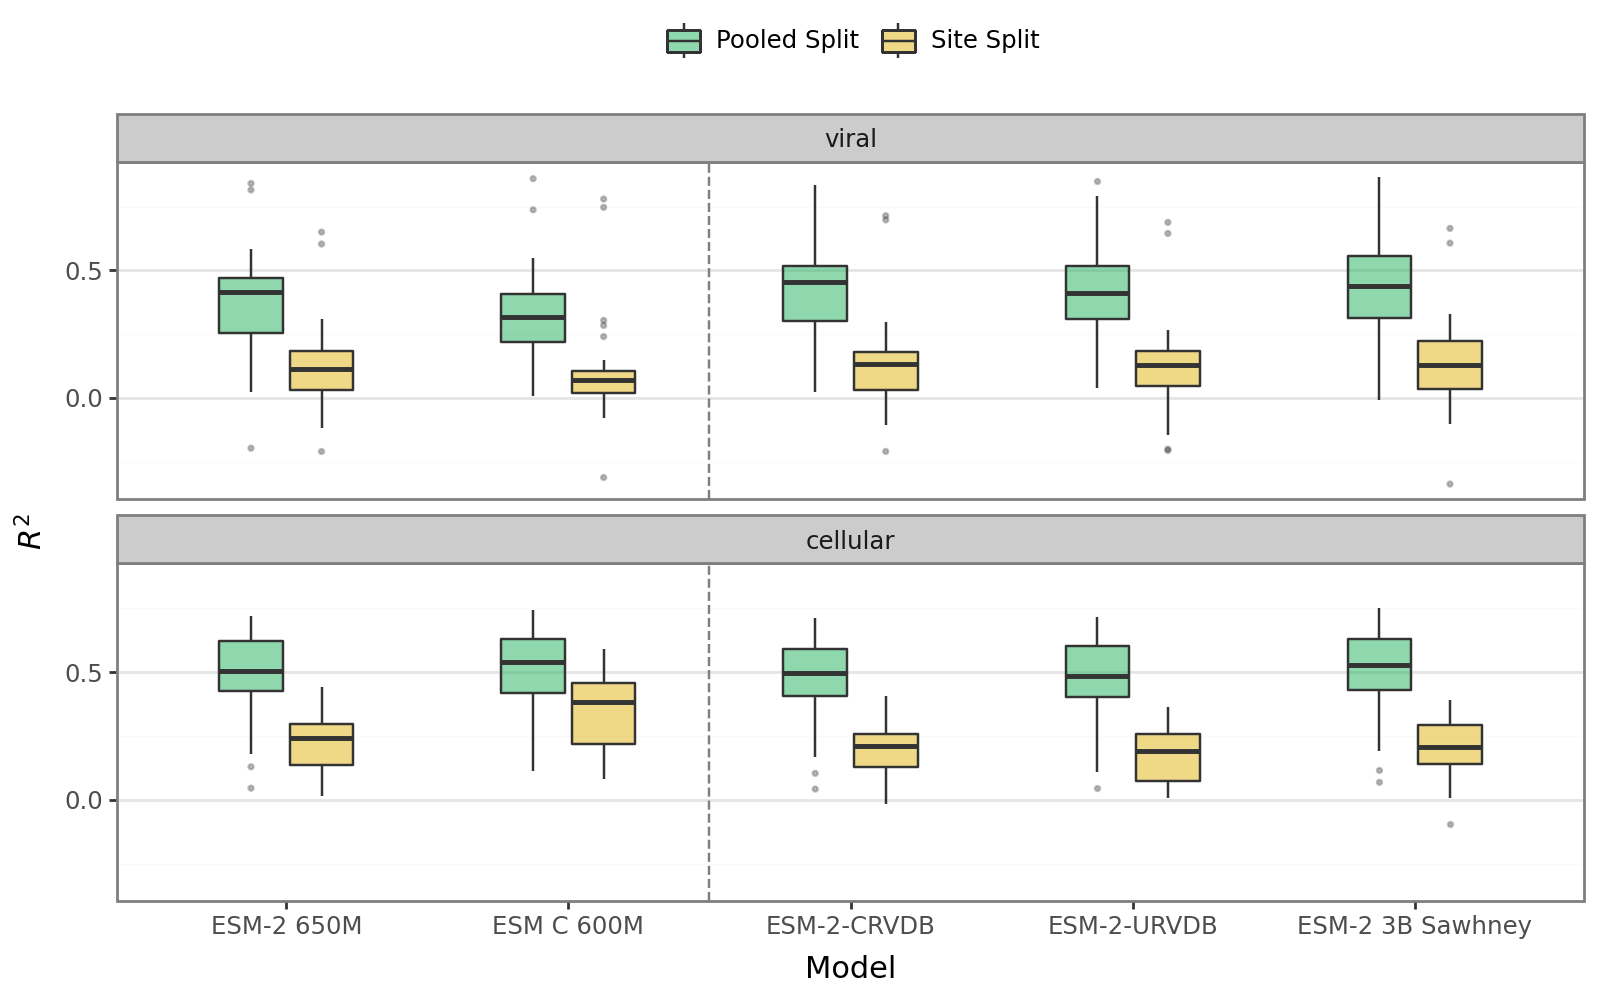

In [38]:
plot = (
    pln.ggplot(res_full, pln.aes(fill='Split', y='R2_score_test', x='Model'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5, alpha=0.5 )
    + pln.geom_vline(xintercept=2.5, linetype='dashed', color='gray', size=0.5)
    + pln.scale_fill_manual(values={"Pooled Split": "#20B15C", "Site Split": "#E2B40E"})
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.facet_wrap('~Source', nrow=2)
    + pln.theme(
        figure_size=(8, 5),
        panel_grid_major_x=pln.element_blank(),
        legend_position='top',
        legend_title=pln.element_blank()
    )
)

plot.save(filename='../experiments/figures/fig4_site_x_random_all_models.png', dpi=600)
plot

In [37]:
full_res.groupby(['Model', 'Split'], as_index=False)['R2_score_test'].mean() 

/tmp/ipykernel_2267237/1555157308.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Model,Split,R2_score_test
0,ESM-2 650M,Pooled Split,0.419492
1,ESM-2 650M,Site Split,0.164085
2,ESM C 600M,Pooled Split,0.404871
3,ESM C 600M,Site Split,0.208900
4,ESM-2-CRVDB,Pooled Split,0.433579
5,ESM-2-CRVDB,Site Split,0.160780
6,ESM-2-URVDB,Pooled Split,0.433359
7,ESM-2-URVDB,Site Split,0.151623
8,ESM-2 3B Sawhney,Pooled Split,0.462026
9,ESM-2 3B Sawhney,Site Split,0.168587


# ESMC

In [5]:
cols = ['R2_score_train', 'MAE_score_train', 'RMSE_score_train','rho_score_train',
       'R2_score_test', 'MAE_score_test', 'RMSE_score_test', 'rho_score_test', 'num_nonzero_coefs']

lassocv = pd.read_csv('../experiments/compiled_results/res_lassoCV_all_models.csv', index_col=0)
lassocv = lassocv.groupby(['Model', 'Source', 'Dataset', 'Split'], as_index=False)[cols].mean()

In [6]:
res_esmc = lassocv.query('Model == "ESM C 600M" and Split == "Pooled Split"').copy()
res_esmc['Source'] = pd.Categorical(res_esmc['Source'], categories=['viral', 'cellular'])
res_esmc['prot_length'] = res_esmc['Dataset'].map(prot_lengths)
res_esmc

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,prot_length
0,ESM C 600M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.544940,0.502568,0.674223,0.763363,0.476794,0.532886,0.723885,0.730510,301.6,346
2,ESM C 600M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.473849,0.583160,0.724281,0.703427,0.420559,0.613820,0.765567,0.667434,335.6,439
4,ESM C 600M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.303514,0.633591,0.835410,0.527946,0.231265,0.664253,0.872660,0.464384,411.0,439
6,ESM C 600M,cellular,BG_STRSQ_hmmerbit,Pooled Split,0.586958,0.462587,0.641609,0.757999,0.539194,0.488546,0.682969,0.731760,118.6,501
8,ESM C 600M,cellular,BLAT_ECOLX_Ostermeier2014,Pooled Split,0.699910,0.431016,0.547510,0.864369,0.653427,0.461392,0.589177,0.837835,229.6,286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,ESM C 600M,viral,SARS2_PLPRO_activity_Wu,Pooled Split,0.484367,0.601993,0.719303,0.680624,0.432833,0.620982,0.747541,0.635793,212.4,316
140,ESM C 600M,viral,SARS2_PRD0038_RBD_Starr,Pooled Split,0.510099,0.511672,0.700721,0.571004,0.437716,0.538448,0.744827,0.542515,162.4,200
142,ESM C 600M,viral,SARS2_RBD_binding_Starr,Pooled Split,0.659006,0.422885,0.580263,0.691303,0.549353,0.493395,0.686356,0.647336,386.6,1273
144,ESM C 600M,viral,SARS2_RBD_expression_Starr,Pooled Split,0.569554,0.533033,0.656195,0.741974,0.462231,0.591231,0.731633,0.659764,227.8,1273


In [13]:
p1 =(
    pln.ggplot(res_esmc, pln.aes(x='prot_length', y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    #+ pln.facet_wrap('Split')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score")
    + pln.theme_bw()
    #+ pln.annotate('text', x=1600, y=0.85, label='ESM C', size=8)
    + pln.theme(figure_size=(7, 5), legend_position='none',legend_title=pln.element_blank())

)
p1.save(filename='../experiments/figures/supp1_lassocv_r2_x_prot_length_esmc.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 7 x 5 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: ../experiments/figures/supp1_lassocv_r2_x_prot_length_esmc.png


In [33]:
res_esm2_3b = lassocv.query('Model == "ESM-2 3B Sawhney" and Split == "Pooled Split"').copy()
res_esm2_3b['Source'] = pd.Categorical(res_esm2_3b['Source'], categories=['viral', 'cellular'])
res_esm2_3b['prot_length'] = res_esm2_3b['Dataset'].map(prot_lengths)
res_esm2_3b

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,prot_length
148,ESM-2 3B Sawhney,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.686110,0.404638,0.559949,0.846561,0.540731,0.479769,0.678163,0.782551,668.6,346
150,ESM-2 3B Sawhney,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.640283,0.470605,0.598871,0.815413,0.523620,0.541194,0.694118,0.746783,853.6,439
152,ESM-2 3B Sawhney,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.411669,0.580821,0.767687,0.607645,0.289827,0.635285,0.838742,0.504102,611.2,439
154,ESM-2 3B Sawhney,cellular,BG_STRSQ_hmmerbit,Pooled Split,0.666018,0.434208,0.576555,0.786734,0.460657,0.544303,0.738902,0.678339,479.8,501
156,ESM-2 3B Sawhney,cellular,BLAT_ECOLX_Ostermeier2014,Pooled Split,0.836750,0.306393,0.403775,0.910085,0.724290,0.399493,0.525347,0.852583,977.8,286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,ESM-2 3B Sawhney,viral,SARS2_PLPRO_activity_Wu,Pooled Split,0.719304,0.420533,0.530712,0.811892,0.578590,0.506825,0.644240,0.733869,688.2,316
288,ESM-2 3B Sawhney,viral,SARS2_PRD0038_RBD_Starr,Pooled Split,0.658775,0.425206,0.584300,0.633911,0.440478,0.510657,0.742009,0.534008,520.8,200
290,ESM-2 3B Sawhney,viral,SARS2_RBD_binding_Starr,Pooled Split,0.811117,0.311198,0.431813,0.798400,0.642902,0.432190,0.610970,0.720056,839.6,1273
292,ESM-2 3B Sawhney,viral,SARS2_RBD_expression_Starr,Pooled Split,0.839041,0.310069,0.400708,0.901457,0.630294,0.456176,0.605747,0.799842,904.6,1273


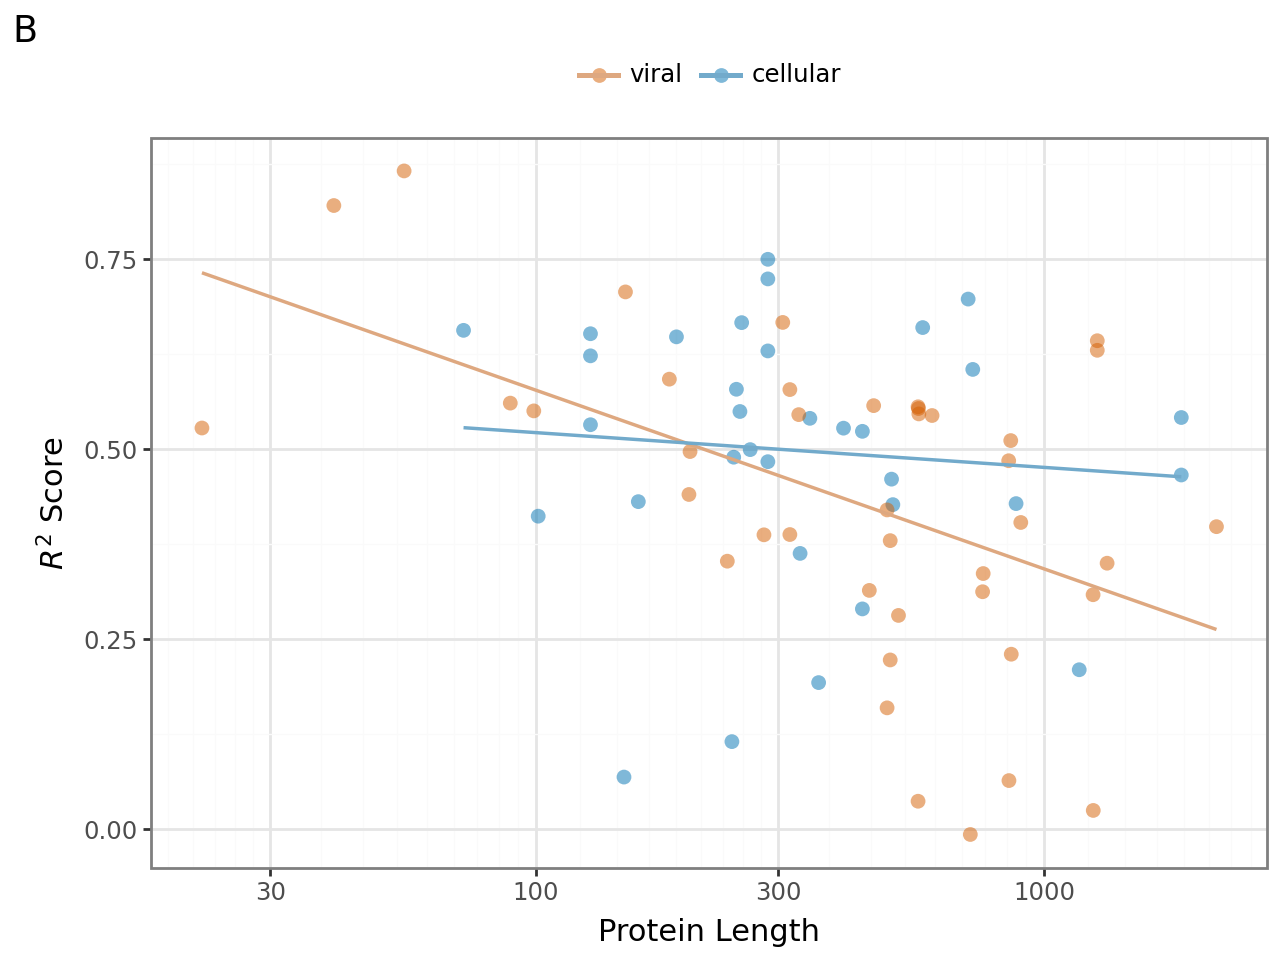

In [34]:
p2 = (
    pln.ggplot(res_esm2_3b, pln.aes(x='prot_length', y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    #+ pln.facet_wrap('Split')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score", tag='B')
    #+ pln.annotate('text', x=900, y=0.85, label='ESM-2 3B Sawhney', size=8)
    + pln.theme_bw()
    + pln.theme(legend_position='top',legend_title=pln.element_blank())

)
p2

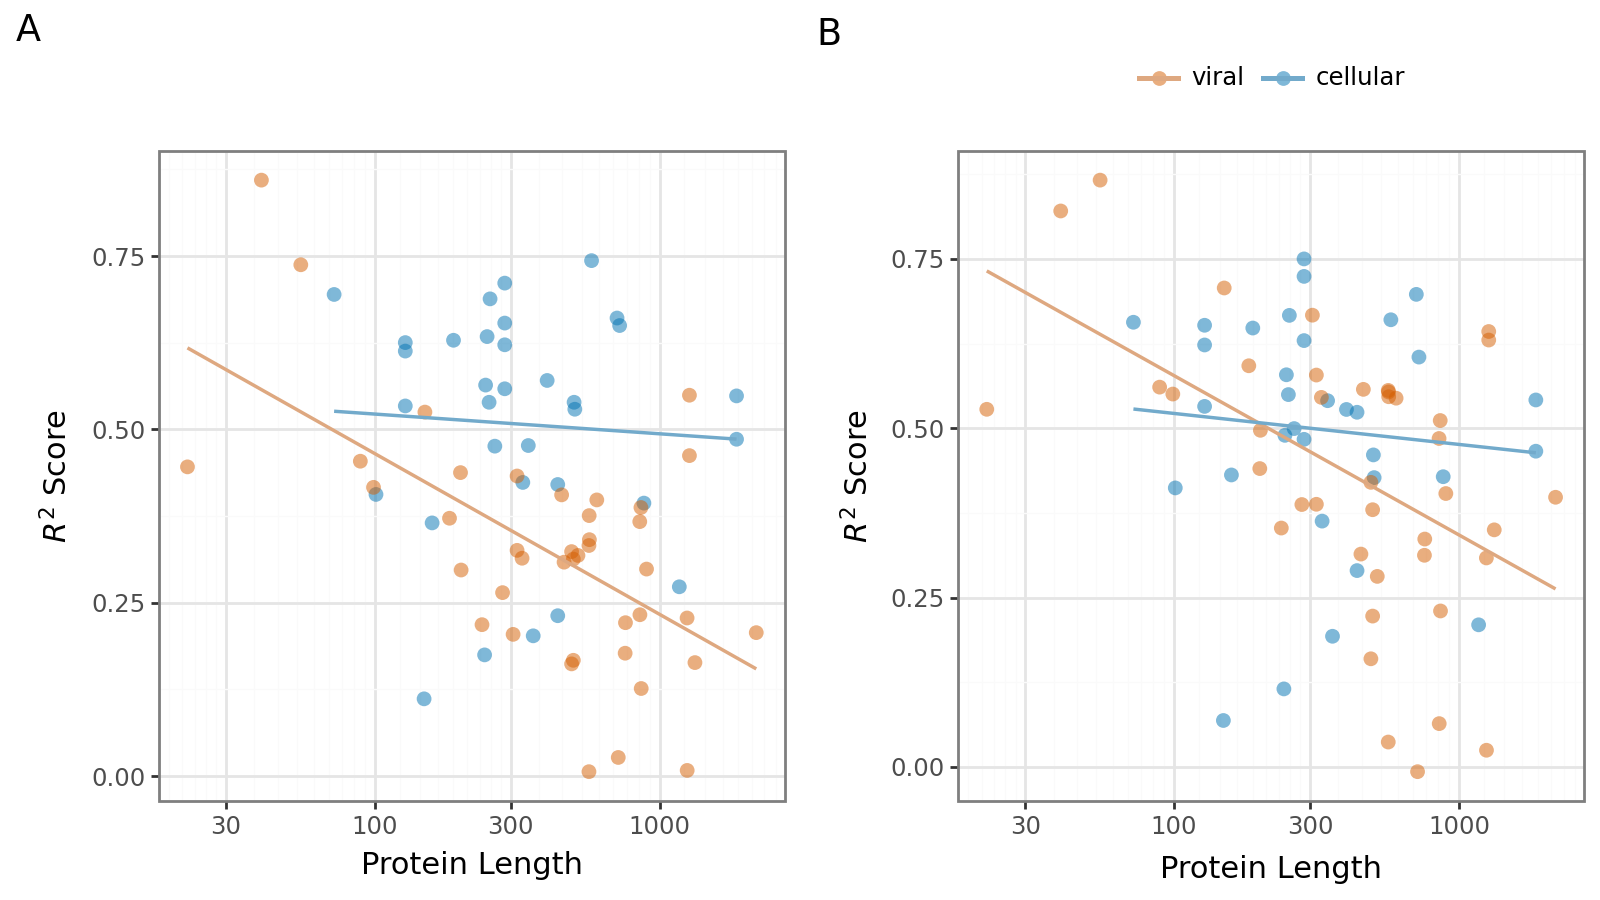

In [38]:
comp = (p1 | p2)
plot = comp + pln.theme(figure_size=(8, 4.5))
plot.save(filename='../experiments/figures/supp1_lassocv_r2_x_prot_length_esmc_esm2-3B.png', dpi=600)
plot